In [5]:
#pip install pybaseball

In [6]:
#pip install seaborn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pybaseball import schedule_and_record, batting_stats, pitching_stats
from pybaseball import statcast, team_batting, team_pitching
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [8]:
from pybaseball import statcast
import time

date_ranges = [
    # 2022
    ('2022-04-07', '2026-03-29')]
    
all_data = []
for start, end in date_ranges:
    print(f"Pulling {start} to {end}...")
    try:
        df = statcast(start_dt=start, end_dt=end)
        all_data.append(df)
        print(f"  Got {len(df)} rows")
    except Exception as e:
        print(f"  Error: {e}")
    time.sleep(3)

statcast_df = pd.concat(all_data, ignore_index=True)
print(f"\nTotal rows: {len(statcast_df)}")
print(f"Date range: {statcast_df['game_date'].min()} to {statcast_df['game_date'].max()}")
print(f"Unique games: {statcast_df['game_pk'].nunique()}")

Pulling 2022-04-07 to 2026-03-29...
This is a large query, it may take a moment to complete
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates


100%|██████████| 976/976 [05:55<00:00,  2.75it/s]


  Got 3079315 rows

Total rows: 3079315
Date range: 2022-04-07 00:00:00 to 2026-03-29 00:00:00
Unique games: 10568


In [9]:
# Filter to first inning only
first_inning = statcast_df[statcast_df['inning'] == 1].copy()

print(f"First inning pitches: {len(first_inning)}")
print(f"Unique games: {first_inning['game_pk'].nunique()}")

# For each game, calculate runs scored in the first inning
# We'll do this for both home and away teams separately

def get_first_inning_runs(df):
    results = []
    
    for game_pk, game in df.groupby('game_pk'):
        # Away team bats in top of 1st
        top = game[game['inning_topbot'] == 'Top']
        # Home team bats in bottom of 1st
        bot = game[game['inning_topbot'] == 'Bot']
        
        if len(top) > 0:
            away_runs = top['post_bat_score'].max() - top['bat_score'].min()
            results.append({
                'game_pk': game_pk,
                'game_date': game['game_date'].iloc[0],
                'team': game['away_team'].iloc[0],
                'opponent': game['home_team'].iloc[0],
                'is_home': 0,
                'first_inning_runs': max(0, away_runs),
                'starting_pitcher': game[game['inning_topbot'] == 'Bot']['pitcher'].iloc[0] if len(bot) > 0 else None,
            })
        
        if len(bot) > 0:
            home_runs = bot['post_bat_score'].max() - bot['bat_score'].min()
            results.append({
                'game_pk': game_pk,
                'game_date': game['game_date'].iloc[0],
                'team': game['home_team'].iloc[0],
                'opponent': game['away_team'].iloc[0],
                'is_home': 1,
                'first_inning_runs': max(0, home_runs),
                'starting_pitcher': game[game['inning_topbot'] == 'Top']['pitcher'].iloc[0] if len(top) > 0 else None,
            })
    
    return pd.DataFrame(results)

print("Aggregating first inning runs...")
fir_df = get_first_inning_runs(first_inning)
print(f"\nTotal team-game records: {len(fir_df)}")
print(f"\nFirst inning runs distribution:")
print(fir_df['first_inning_runs'].value_counts().sort_index())
print(f"\nMean first inning runs: {fir_df['first_inning_runs'].mean():.3f}")
print(f"Scored in 1st inning rate: {(fir_df['first_inning_runs'] > 0).mean():.3f}")

First inning pitches: 355605
Unique games: 10568
Aggregating first inning runs...

Total team-game records: 21136

First inning runs distribution:
first_inning_runs
0     15078
1      3285
2      1521
3       747
4       306
5       125
6        47
7        13
8         2
9         9
10        3
Name: count, dtype: int64

Mean first inning runs: 0.517
Scored in 1st inning rate: 0.287


In [10]:
# Binary target for classification
fir_df['scored'] = (fir_df['first_inning_runs'] > 0).astype(int)

# Add day of season for potential trend features
fir_df['game_date'] = pd.to_datetime(fir_df['game_date'])
fir_df = fir_df.sort_values('game_date').reset_index(drop=True)

print("Targets created:")
print(f"Classification — scored in 1st: {fir_df['scored'].mean():.3f}")
print(f"Regression — mean runs: {fir_df['first_inning_runs'].mean():.3f}")
print(f"\nDate range: {fir_df['game_date'].min()} to {fir_df['game_date'].max()}")
print(f"\nSample records:")
print(fir_df.head(10).to_string(index=False))

Targets created:
Classification — scored in 1st: 0.287
Regression — mean runs: 0.517

Date range: 2022-04-07 00:00:00 to 2026-03-29 00:00:00

Sample records:
 game_pk  game_date team opponent  is_home  first_inning_runs  starting_pitcher  scored
  661577 2022-04-07  ATL      CIN        1                  0            608331       0
  662021 2022-04-07  STL      PIT        1                  1            425794       1
  662766 2022-04-07   KC      CLE        1                  0            425844       0
  662766 2022-04-07  CLE       KC        0                  0            669456       0
  663418 2022-04-07   SD       AZ        0                  0            506433       0
  663418 2022-04-07   AZ       SD        1                  0            518516       0
  662571 2022-04-07  NYM      WSH        0                  0            656731       0
  661577 2022-04-07  CIN      ATL        0                  0            641816       0
  661042 2022-04-07  LAA      HOU        1        

In [11]:
from pybaseball import playerid_reverse_lookup

pitcher_ids = fir_df['starting_pitcher'].dropna().unique().tolist()
pitcher_ids = [int(p) for p in pitcher_ids]
print(f"Unique starting pitchers: {len(pitcher_ids)}")
id_map = playerid_reverse_lookup(pitcher_ids, key_type='mlbam')
id_map['pitcher_name'] = id_map['name_first'] + ' ' + id_map['name_last']
id_map = id_map[['key_mlbam', 'key_fangraphs', 'pitcher_name']].copy()
id_map.columns = ['starting_pitcher', 'pitcher_fgid', 'pitcher_name']
print(f"Mapped {len(id_map)} pitchers")

Unique starting pitchers: 876
Gathering player lookup table. This may take a moment.
Mapped 808 pitchers


In [12]:
from pybaseball import pitching_stats

all_pitcher_stats = []
for year in [2022, 2023, 2024, 2025]:
    try:
        ps = pitching_stats(year, qual=10)
        ps['season'] = year
        all_pitcher_stats.append(ps)
        print(f"Loaded {year} pitcher stats: {len(ps)} pitchers")
    except Exception as e:
        print(f"Error {year}: {e}")
    time.sleep(2)

pitch_stats_all = pd.concat(all_pitcher_stats, ignore_index=True)
print(f"Total pitcher-seasons: {len(pitch_stats_all)}")

Loaded 2022 pitcher stats: 649 pitchers
Loaded 2023 pitcher stats: 659 pitchers
Loaded 2024 pitcher stats: 656 pitchers
Loaded 2025 pitcher stats: 657 pitchers
Total pitcher-seasons: 2621


In [13]:
PITCHER_FEATURES = ['IDfg', 'Season', 'Name', 'ERA', 'FIP', 'xFIP', 'SIERA',
                    'K%', 'BB%', 'K-BB%', 'WHIP', 'HR/9', 'GB%',
                    'SwStr%', 'CSW%', 'HardHit%', 'xERA']

pitcher_df = pitch_stats_all[PITCHER_FEATURES].copy()
pitcher_df.columns = ['pitcher_fgid', 'season', 'pitcher_name'] + \
                     [f'sp_{c}' for c in PITCHER_FEATURES[3:]]

# Add season to fir_df for matching
fir_df['season'] = pd.to_datetime(fir_df['game_date']).dt.year

# Merge id map
fir_df = fir_df.merge(id_map, on='starting_pitcher', how='left')

# Merge pitcher stats by pitcher + season
pitcher_df_merge = pitcher_df.drop(columns=['pitcher_name'])
fir_df = fir_df.merge(pitcher_df_merge, on=['pitcher_fgid', 'season'], how='left')

print(f"Merged dataset shape: {fir_df.shape}")
print(f"Missing pitcher stats: {fir_df['sp_ERA'].isna().sum()} rows ({fir_df['sp_ERA'].isna().mean():.1%})")

Merged dataset shape: (21136, 25)
Missing pitcher stats: 2028 rows (9.6%)


In [14]:
pitcher_stat_cols = ['sp_ERA', 'sp_FIP', 'sp_xFIP', 'sp_SIERA', 'sp_K%',
                     'sp_BB%', 'sp_K-BB%', 'sp_WHIP', 'sp_HR/9', 'sp_GB%',
                     'sp_SwStr%', 'sp_CSW%', 'sp_HardHit%', 'sp_xERA']

for col in pitcher_stat_cols:
    fir_df[col] = fir_df[col].fillna(fir_df[col].median())

fir_df['month'] = fir_df['game_date'].dt.month

fir_df = fir_df.sort_values(['team', 'game_date']).reset_index(drop=True)
fir_df['team_rolling_runs'] = (
    fir_df.groupby('team')['first_inning_runs']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
)
fir_df['team_rolling_runs'] = fir_df.groupby('team')['team_rolling_runs'].transform(
    lambda x: x.fillna(x.median())
)

FEATURES = [
    'sp_ERA', 'sp_FIP', 'sp_xFIP', 'sp_SIERA',
    'sp_K%', 'sp_BB%', 'sp_K-BB%', 'sp_WHIP',
    'sp_HR/9', 'sp_GB%', 'sp_SwStr%', 'sp_CSW%',
    'sp_HardHit%', 'sp_xERA',
    'is_home', 'month', 'team_rolling_runs'
]

model_df = fir_df[FEATURES + ['first_inning_runs', 'scored']].dropna()
print(f"Final modeling dataset shape: {model_df.shape}")
print(f"Scored rate: {model_df['scored'].mean():.3f}")
print(f"Mean runs: {model_df['first_inning_runs'].mean():.3f}")

Final modeling dataset shape: (21136, 19)
Scored rate: 0.287
Mean runs: 0.517


In [15]:
FEATURES = [
    'sp_ERA', 'sp_FIP', 'sp_xFIP', 'sp_SIERA',
    'sp_K%', 'sp_BB%', 'sp_K-BB%', 'sp_WHIP',
    'sp_HR/9', 'sp_GB%', 'sp_SwStr%', 'sp_CSW%',
    'sp_HardHit%', 'sp_xERA',
    'is_home', 'month', 'team_rolling_runs'
]

model_df = fir_df[FEATURES + ['first_inning_runs', 'scored']].dropna()

print(f"Modeling dataset shape: {model_df.shape}")
print(f"\nFeature correlations with first_inning_runs:")
corr = model_df[FEATURES].corrwith(model_df['first_inning_runs']).sort_values()
print(corr.to_string())

Modeling dataset shape: (21136, 19)

Feature correlations with first_inning_runs:
month               -0.003959
sp_WHIP             -0.003220
sp_K-BB%            -0.002396
sp_SwStr%           -0.001143
sp_ERA              -0.000587
sp_K%               -0.000555
sp_xERA              0.000200
sp_CSW%              0.002074
sp_xFIP              0.002839
sp_BB%               0.004571
sp_SIERA             0.004883
sp_HR/9              0.005655
sp_FIP               0.006673
sp_GB%               0.007026
team_rolling_runs    0.011365
sp_HardHit%          0.012208
is_home              0.051568


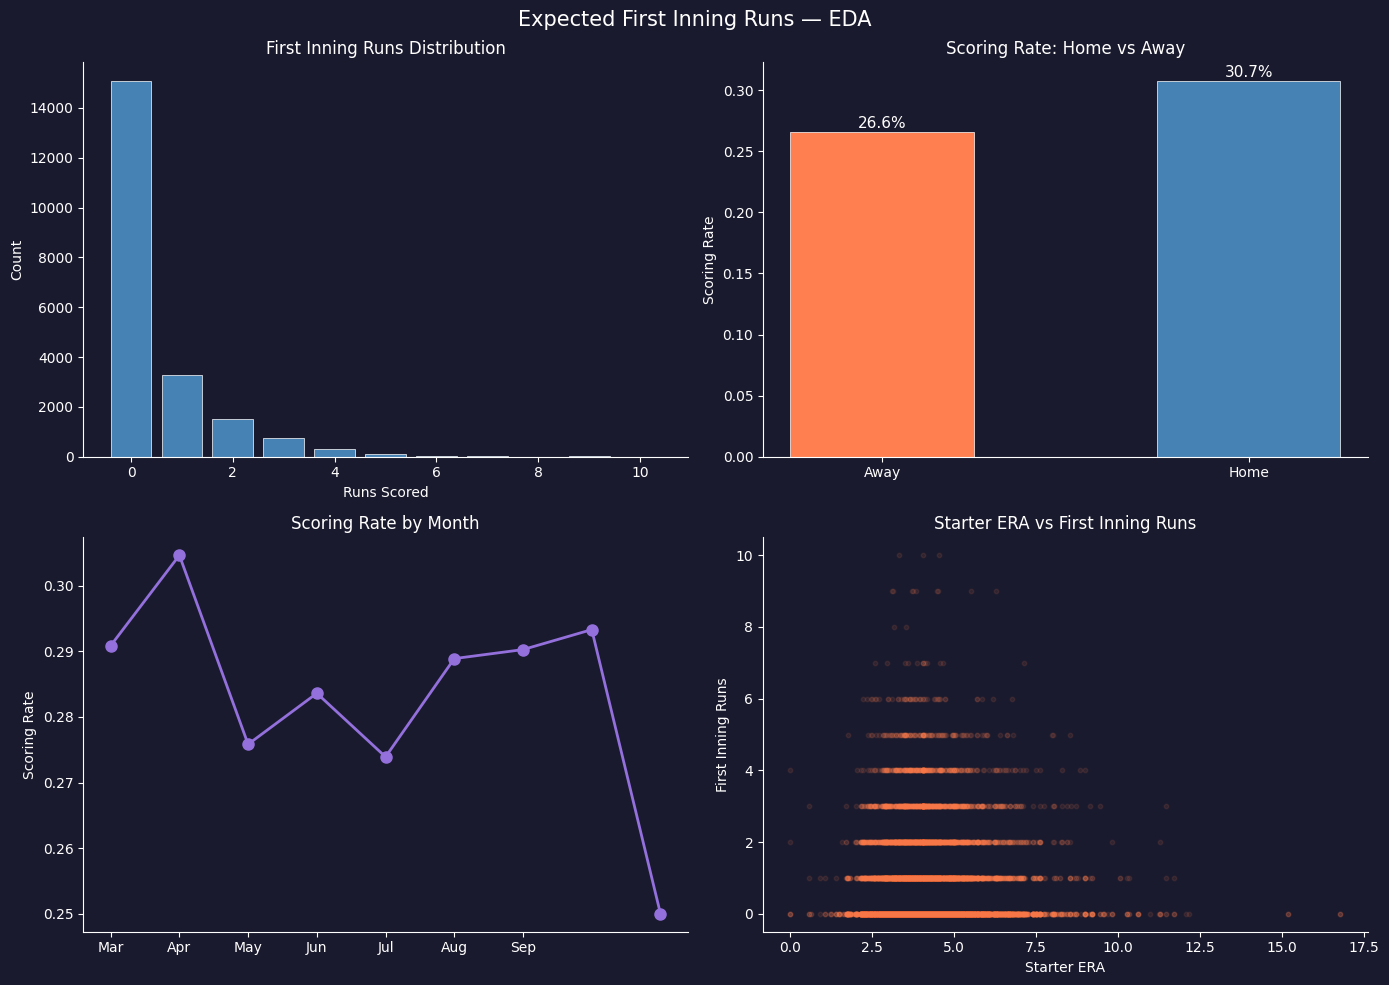

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#1a1a2e')

# 1. Run distribution
axes[0,0].set_facecolor('#1a1a2e')
counts = model_df['first_inning_runs'].value_counts().sort_index()
axes[0,0].bar(counts.index, counts.values, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0,0].set_title('First Inning Runs Distribution', color='white', fontsize=12)
axes[0,0].set_xlabel('Runs Scored', color='white')
axes[0,0].set_ylabel('Count', color='white')
axes[0,0].tick_params(colors='white')
for spine in ['top', 'right']:
    axes[0,0].spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    axes[0,0].spines[spine].set_color('white')

# 2. Scoring rate home vs away
axes[0,1].set_facecolor('#1a1a2e')
home_rate = model_df.groupby('is_home')['scored'].mean()
axes[0,1].bar(['Away', 'Home'], home_rate.values, color=['coral', 'steelblue'], 
              edgecolor='white', linewidth=0.5, width=0.5)
for i, v in enumerate(home_rate.values):
    axes[0,1].text(i, v + 0.003, f'{v:.1%}', ha='center', color='white', fontsize=11)
axes[0,1].set_title('Scoring Rate: Home vs Away', color='white', fontsize=12)
axes[0,1].set_ylabel('Scoring Rate', color='white')
axes[0,1].tick_params(colors='white')
for spine in ['top', 'right']:
    axes[0,1].spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    axes[0,1].spines[spine].set_color('white')

# 3. Scoring rate by month
axes[1,0].set_facecolor('#1a1a2e')
month_rate = model_df.groupby('month')['scored'].mean()
month_names = {3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
               7: 'Jul', 8: 'Aug', 9: 'Sep'}
axes[1,0].plot(month_rate.index, month_rate.values, 
               color='mediumpurple', linewidth=2, marker='o', markersize=8)
axes[1,0].set_xticks(list(month_names.keys()))
axes[1,0].set_xticklabels(list(month_names.values()), color='white')
axes[1,0].set_title('Scoring Rate by Month', color='white', fontsize=12)
axes[1,0].set_ylabel('Scoring Rate', color='white')
axes[1,0].tick_params(colors='white')
for spine in ['top', 'right']:
    axes[1,0].spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    axes[1,0].spines[spine].set_color('white')

# 4. ERA vs first inning runs scatter
axes[1,1].set_facecolor('#1a1a2e')
axes[1,1].scatter(model_df['sp_ERA'], model_df['first_inning_runs'], 
                  alpha=0.1, color='coral', s=10)
axes[1,1].set_title('Starter ERA vs First Inning Runs', color='white', fontsize=12)
axes[1,1].set_xlabel('Starter ERA', color='white')
axes[1,1].set_ylabel('First Inning Runs', color='white')
axes[1,1].tick_params(colors='white')
for spine in ['top', 'right']:
    axes[1,1].spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    axes[1,1].spines[spine].set_color('white')

plt.suptitle('Expected First Inning Runs — EDA', color='white', fontsize=15)
plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## EDA Key Findings

**Run Distribution**
First inning scoring is heavily zero-inflated — 72.6% of half-innings result
in no runs scored. This motivates both a classification approach (did they
score?) and a regression approach (how many runs?).

**Home Field Advantage**
Home teams score in the first inning at a 28.7% rate vs 26.1% for away teams.
While modest, this is consistent with broader home field research in baseball.

**Seasonal Trends**
Scoring rate dips notably in May before recovering through summer. This may
reflect early-season lineup adjustments or weather effects in northern markets.

**Starter ERA vs First Inning Runs**
The scatter plot shows no clear linear relationship between starter ERA and
first inning runs — confirming that first inning scoring is highly stochastic.
This sets realistic expectations for model performance.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = model_df[FEATURES]
y_class = model_df['scored']
y_reg = model_df['first_inning_runs']

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Scoring rate train: {yc_train.mean():.3f}")
print(f"Scoring rate test: {yc_test.mean():.3f}")

Train size: 16908
Test size: 4228
Scoring rate train: 0.287
Scoring rate test: 0.287


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
from xgboost import XGBClassifier

# Logistic Regression
lr_c = LogisticRegression(random_state=42, max_iter=1000)
lr_c.fit(X_train_scaled, yc_train)
lr_c_probs = lr_c.predict_proba(X_test_scaled)[:, 1]

# XGBoost
xgb_c = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
xgb_c.fit(X_train, yc_train)
xgb_c_probs = xgb_c.predict_proba(X_test)[:, 1]

# Naive baseline — always predict league average
baseline_prob = yc_train.mean()
baseline_probs = np.full(len(yc_test), baseline_prob)

print("=== CLASSIFICATION RESULTS ===")
print(f"{'Model':<25} {'Log Loss':>10} {'Brier':>10} {'ROC-AUC':>10}")
print("-" * 58)
for name, probs in [('Logistic Regression', lr_c_probs),
                     ('XGBoost', xgb_c_probs),
                     ('Baseline (avg)', baseline_probs)]:
    print(f"{name:<25} {log_loss(yc_test, probs):>10.4f} "
          f"{brier_score_loss(yc_test, probs):>10.4f} "
          f"{roc_auc_score(yc_test, probs):>10.4f}")

=== CLASSIFICATION RESULTS ===
Model                       Log Loss      Brier    ROC-AUC
----------------------------------------------------------
Logistic Regression           0.5992     0.2045     0.5220
XGBoost                       0.6041     0.2065     0.5074
Baseline (avg)                0.5991     0.2045     0.5000


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# Linear Regression
lr_r = LinearRegression()
lr_r.fit(X_train_scaled, yr_train)
lr_r_preds = lr_r.predict(X_test_scaled)

# XGBoost Regressor
xgb_r = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42
)
xgb_r.fit(X_train, yr_train)
xgb_r_preds = xgb_r.predict(X_test)

# Naive baseline — always predict mean runs
baseline_runs = yr_train.mean()
baseline_preds = np.full(len(yr_test), baseline_runs)

print("=== REGRESSION RESULTS ===")
print(f"{'Model':<25} {'RMSE':>10} {'MAE':>10}")
print("-" * 48)
for name, preds in [('Linear Regression', lr_r_preds),
                     ('XGBoost', xgb_r_preds),
                     ('Baseline (mean)', baseline_preds)]:
    rmse = np.sqrt(mean_squared_error(yr_test, preds))
    mae = mean_absolute_error(yr_test, preds)
    print(f"{name:<25} {rmse:>10.4f} {mae:>10.4f}")

=== REGRESSION RESULTS ===
Model                           RMSE        MAE
------------------------------------------------
Linear Regression             1.0449     0.7475
XGBoost                       1.0484     0.7460
Baseline (mean)               1.0454     0.7479


In [21]:
# 2024 park factors from Baseball Reference (runs, normalized to 100 = average)
park_factors = {
    'COL': 115,  # Coors — perennial #1
    'ATH': 112,  # Sutter Health Park — emerged as major hitter's park in 2025
    'CIN': 108,  # Great American — top HR park
    'BAL': 107,  # Camden Yards renovations kept it elite
    'DET': 106,  # Comerica surprised in 2025
    'LAD': 106,  # Dodger Stadium now top HR park
    'BOS': 105,  # Fenway — consistent
    'TOR': 105,  # Rogers Centre — hitter friendly
    'KCR': 105,  # Kauffman — wall renovation boosts this significantly in 2026
    'MIL': 104,  # American Family Field
    'PHI': 104,  # Citizens Bank
    'MIN': 103,  # Target Field — new to hitter tier
    'NYY': 103,  # Yankee Stadium
    'ATL': 102,  # Truist Park
    'HOU': 102,  # Daikin Park
    'STL': 99,   # Busch — limits scoring and strikeouts
    'PIT': 98,   # PNC Park
    'MIA': 98,   # loanDepot
    'CHC': 97,   # Wrigley — dropped from hitter tier
    'NYM': 97,   # Citi Field
    'SDP': 97,   # Petco — pitcher's park
    'LAA': 96,   # Angel Stadium
    'SF':  96,   # Oracle Park
    'ARI': 100,  # Chase Field — neutral
    'CLE': 95,   # Progressive Field — suppresses scoring
    'WSN': 95,   # Nationals Park
    'CHW': 94,   # Guaranteed Rate
    'TBR': 94,   # Tropicana — new roof, returns to pitcher's park
    'SEA': 93,   # T-Mobile — consistently one of MLB's worst for hitters
    'TEX': 93,   # Globe Life — tied with T-Mobile as offense suppressor
}

# Map park factor to home team
fir_df['park_factor'] = fir_df.apply(
    lambda row: park_factors.get(row['team'] if row['is_home'] == 1 
                                 else row['opponent'], 100), axis=1
)

print("Park factors added:")
print(fir_df.groupby('team')['park_factor'].first().sort_values(ascending=False))

Park factors added:
team
COL    115
LAD    115
DET    106
CWS    106
TOR    105
TEX    105
PHI    104
ATH    104
SEA    103
NYY    103
BOS    103
MIN    103
CIN    102
ATL    102
TB     100
WSH    100
SD     100
KC     100
BAL    100
AZ     100
CLE    100
NYM    100
STL     99
PIT     99
CHC     97
MIL     97
LAA     96
HOU     96
MIA     96
SF      96
Name: park_factor, dtype: int64


In [22]:
from pybaseball import batting_stats

all_batting = []
for year in [2022, 2023, 2024, 2025]:
    try:
        bs = batting_stats(year, qual=50)
        bs['season'] = year
        all_batting.append(bs)
        print(f"Loaded {year} batting stats: {len(bs)} players")
    except Exception as e:
        print(f"Error {year}: {e}")
    time.sleep(2)

batting_df = pd.concat(all_batting, ignore_index=True)

# Get team-level OPS and wRC+ by season
team_offense = batting_df.groupby(['Team', 'season']).agg(
    team_OPS=('OPS', 'mean'),
    team_wRC=('wRC+', 'mean'),
    team_BB_pct=('BB%', 'mean'),
    team_K_pct=('K%', 'mean')
).reset_index()

team_offense.columns = ['team', 'season', 'team_OPS', 'team_wRC', 
                         'team_BB_pct', 'team_K_pct']

print(f"\nTeam offense shape: {team_offense.shape}")
print(team_offense.sort_values('team_wRC', ascending=False).head(10).to_string(index=False))

Loaded 2022 batting stats: 547 players
Loaded 2023 batting stats: 542 players
Loaded 2024 batting stats: 526 players
Loaded 2025 batting stats: 537 players

Team offense shape: (124, 6)
team  season  team_OPS   team_wRC  team_BB_pct  team_K_pct
 TOR    2022  0.762250 119.083333     0.081500    0.190333
 NYY    2022  0.768429 118.214286     0.096000    0.216571
 ATL    2023  0.807769 115.538462     0.077077    0.222769
 TEX    2023  0.777267 114.933333     0.102733    0.225933
 SEA    2023  0.745286 113.142857     0.100357    0.277571
 TOR    2023  0.770500 112.714286     0.087929    0.204643
 NYY    2025  0.759714 111.928571     0.099714    0.227143
 TOR    2025  0.755333 111.333333     0.084267    0.195267
 ARI    2024  0.756529 109.647059     0.089353    0.211000
 BAL    2024  0.736154 109.461538     0.076615    0.225846


In [23]:
# Add season to fir_df if not already there
fir_df['season'] = pd.to_datetime(fir_df['game_date']).dt.year

# Merge team offense
fir_df = fir_df.merge(team_offense, on=['team', 'season'], how='left')

# Fill missing with league average
for col in ['team_OPS', 'team_wRC', 'team_BB_pct', 'team_K_pct']:
    fir_df[col] = fir_df[col].fillna(fir_df[col].median())

print(f"Dataset shape after new features: {fir_df.shape}")
print(f"Missing values: {fir_df[['park_factor', 'team_OPS', 'team_wRC']].isna().sum().to_dict()}")

# Check correlation of new features with target
new_features = ['park_factor', 'team_OPS', 'team_wRC', 'team_BB_pct', 'team_K_pct']
for feat in new_features:
    corr = fir_df[feat].corr(fir_df['first_inning_runs'])
    print(f"{feat}: {corr:.4f}")

Dataset shape after new features: (21136, 32)
Missing values: {'park_factor': 0, 'team_OPS': 0, 'team_wRC': 0}
park_factor: 0.0169
team_OPS: 0.0449
team_wRC: 0.0436
team_BB_pct: 0.0240
team_K_pct: -0.0191


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBClassifier, XGBRegressor

FEATURES_V2 = [
    # Pitcher features
    'sp_ERA', 'sp_FIP', 'sp_xFIP', 'sp_SIERA',
    'sp_K%', 'sp_BB%', 'sp_K-BB%', 'sp_WHIP',
    'sp_HR/9', 'sp_GB%', 'sp_SwStr%', 'sp_CSW%',
    'sp_HardHit%', 'sp_xERA',
    # Game context
    'is_home', 'month', 'team_rolling_runs',
    # New features
    'park_factor', 'team_OPS', 'team_wRC',
    'team_BB_pct', 'team_K_pct'
]

model_df_v2 = fir_df[FEATURES_V2 + ['first_inning_runs', 'scored']].dropna()

X = model_df_v2[FEATURES_V2]
y_class = model_df_v2['scored']
y_reg = model_df_v2['first_inning_runs']

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

scaler_v2 = StandardScaler()
X_train_scaled = scaler_v2.fit_transform(X_train)
X_test_scaled = scaler_v2.transform(X_test)

# Classification
lr_c = LogisticRegression(random_state=42, max_iter=1000)
lr_c.fit(X_train_scaled, yc_train)
lr_c_probs = lr_c.predict_proba(X_test_scaled)[:, 1]

xgb_c = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
xgb_c.fit(X_train, yc_train)
xgb_c_probs = xgb_c.predict_proba(X_test)[:, 1]

# Regression
lr_r = LinearRegression()
lr_r.fit(X_train_scaled, yr_train)
lr_r_preds = lr_r.predict(X_test_scaled)

xgb_r = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42
)
xgb_r.fit(X_train, yr_train)
xgb_r_preds = xgb_r.predict(X_test)

baseline_prob = yc_train.mean()
baseline_probs = np.full(len(yc_test), baseline_prob)
baseline_runs = yr_train.mean()
baseline_preds = np.full(len(yr_test), baseline_runs)

print("=== CLASSIFICATION RESULTS V2 ===")
print(f"{'Model':<25} {'Log Loss':>10} {'Brier':>10} {'ROC-AUC':>10}")
print("-" * 58)
for name, probs in [('Logistic Regression', lr_c_probs),
                     ('XGBoost', xgb_c_probs),
                     ('Baseline (avg)', baseline_probs)]:
    print(f"{name:<25} {log_loss(yc_test, probs):>10.4f} "
          f"{brier_score_loss(yc_test, probs):>10.4f} "
          f"{roc_auc_score(yc_test, probs):>10.4f}")

print("\n=== REGRESSION RESULTS V2 ===")
print(f"{'Model':<25} {'RMSE':>10} {'MAE':>10}")
print("-" * 48)
for name, preds in [('Linear Regression', lr_r_preds),
                     ('XGBoost', xgb_r_preds),
                     ('Baseline (mean)', baseline_preds)]:
    rmse = np.sqrt(mean_squared_error(yr_test, preds))
    mae = mean_absolute_error(yr_test, preds)
    print(f"{name:<25} {rmse:>10.4f} {mae:>10.4f}")

=== CLASSIFICATION RESULTS V2 ===
Model                       Log Loss      Brier    ROC-AUC
----------------------------------------------------------
Logistic Regression           0.5977     0.2039     0.5370
XGBoost                       0.6029     0.2060     0.5228
Baseline (avg)                0.5991     0.2045     0.5000

=== REGRESSION RESULTS V2 ===
Model                           RMSE        MAE
------------------------------------------------
Linear Regression             1.0432     0.7451
XGBoost                       1.0466     0.7439
Baseline (mean)               1.0454     0.7479


In [25]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save best classification model (XGBoost edges LR on AUC)
joblib.dump(xgb_c, '../models/xfir_classifier.pkl')
joblib.dump(lr_c, '../models/xfir_lr_classifier.pkl')

# Save best regression model (Linear Regression edges XGB on RMSE)
joblib.dump(lr_r, '../models/xfir_regressor.pkl')
joblib.dump(xgb_r, '../models/xfir_xgb_regressor.pkl')

# Save scaler
joblib.dump(scaler_v2, '../models/scaler_v2.pkl')

# Save feature list
import json
with open('../models/features_v2.json', 'w') as f:
    json.dump(FEATURES_V2, f)

print("All models saved.")

All models saved.


In [26]:
import json

# Export 2025 pitcher stats
pitchers_2025 = pitcher_df[pitcher_df['season'] == 2025].copy() if 'season' in pitcher_df.columns else pitcher_df.copy()
pitchers_2025.to_csv('../data/pitchers_2025.csv', index=False)

# Export 2025 team offense
team_offense_2025 = team_offense[team_offense['season'] == 2025].copy()
team_offense_2025.to_csv('../data/team_offense_2025.csv', index=False)

# Export full pitcher list for dropdown
pitcher_list = pitchers_2025[['pitcher_fgid', 'pitcher_name', 'sp_ERA', 'sp_FIP', 
                               'sp_xFIP', 'sp_SIERA', 'sp_K%', 'sp_BB%', 'sp_K-BB%',
                               'sp_WHIP', 'sp_HR/9', 'sp_GB%', 'sp_SwStr%', 
                               'sp_CSW%', 'sp_HardHit%', 'sp_xERA']].copy()
pitcher_list = pitcher_list.sort_values('pitcher_name')
pitcher_list.to_csv('../data/pitcher_list_2025.csv', index=False)

print(f"Pitchers exported: {len(pitcher_list)}")
print(f"Teams exported: {len(team_offense_2025)}")
print(pitcher_list.head())
print(team_offense_2025.head())

Pitchers exported: 657
Teams exported: 31
      pitcher_fgid      pitcher_name  sp_ERA  sp_FIP  sp_xFIP  sp_SIERA  \
2365         31764     A.J. Blubaugh    1.69    4.42     4.10      3.54   
2312         18655       A.J. Minter    1.64    1.95     3.21      3.15   
2219         29960  AJ Smith-Shawver    3.86    3.90     4.36      4.60   
2114         23550       Aaron Ashby    2.16    2.70     2.97      2.89   
2263         16258      Aaron Bummer    3.81    3.52     3.68      3.39   

      sp_K%  sp_BB%  sp_K-BB%  sp_WHIP  sp_HR/9  sp_GB%  sp_SwStr%  sp_CSW%  \
2365  0.282   0.089     0.194     0.88     1.69   0.338      0.134    0.278   
2312  0.318   0.114     0.205     1.00     0.00   0.480      0.124    0.323   
2219  0.219   0.109     0.109     1.42     0.81   0.354      0.113    0.283   
2114  0.281   0.089     0.193     1.17     0.41   0.620      0.102    0.306   
2263  0.217   0.072     0.145     1.25     0.50   0.539      0.090    0.303   

      sp_HardHit%  sp_xERA  
236